In [1]:
import os
import sys
import argparse
import datetime
from argparse import ArgumentError
from pathlib import Path
from urllib import request

import numpy as np
from numpy.f2py.auxfuncs import throw_error
from prompt_toolkit.output import color_depth

from sentinelhub import (
            SHConfig, BBox, CRS, DataCollection, MimeType,
            SentinelHubRequest, bbox_to_dimensions,
        )

import rasterio
from rasterio.transform import from_bounds
from rasterio.crs import CRS as RioCRS

from oauthlib.oauth2 import BackendApplicationClient
from requests_oauthlib import OAuth2Session

In [27]:
'''
B04          - Red                              - DN => FV*1000
B08          - NIR                              - DN => FV*1000
observations - The number of valid observations
dataMask     - The mask of data/no data pixels

For each pixel, for each band (B02, B03, B04, B08): Take the value of the first quartile and multiply it by 10000 (to get a ‘digital number’). This is an output value.

For each pixel, for each band (B02, B03, B04, B08): If there are no valid observations, output the value -32768, which represents no data
For the observations band, output the value 0, which also represents no data
'''

Bands=["B04", "B08", "observations", "dataMask"]

# input_bands_str = ", ".join([f'"{b}"' for b in Bands])
# return_values_str = ", ".join([f"samples.{b}" for b in Bands])

EVALSCRIPT = f"""
//VERSION=3
function setup() {{
    return {{
        input: [{", ".join([f'"{b}"' for b in Bands])}],
        output: {{
            id: "default",
            bands: {len(Bands)},
            sampleType: "FLOAT32"
        }}
    }};
}}

function evaluatePixel(samples) {{
    return [{", ".join([f"samples.{b}" for b in Bands])}];
}}
"""


In [3]:
QUARTERS = [
    ("01-01", "03-31"),
    ("04-01", "06-30"),
    ("07-01", "09-30"),
    ("10-01", "12-31"),
]

In [4]:
CLIENT_ID     = "NOT_SET"
CLIENT_SECRET = "NOT_SET"

AOI_BBOX = {
    "west":  18.50000,  # ←
    "south": 48.77910,  # ↓
    "east":  18.83029,  # →
    "north": 49.01070,  # ↑
}

bbox = BBox(
        bbox=(AOI_BBOX["west"], AOI_BBOX["south"],
              AOI_BBOX["east"], AOI_BBOX["north"]),
        crs=CRS.WGS84,
    )

OUTPUT_DIR    = Path("../_output")
COLLECTION_ID = "5460de54-082e-473a-b6ea-d5cbe3c17cca"   # 10 m quarterly mosaic
RESOLUTION_M  = 10

In [5]:
def qarter_to_interval(year: int, quarter: int):
    if quarter < 0 or quarter > 4:
        raise ArgumentError(f"Quarter must be from 1 to 4 not {quarter}")

    s, e = QUARTERS[quarter-1]
    return f"{year}-{s}", f"{year}-{e}"

In [6]:

'''
https://sentinelhub-py.readthedocs.io/en/latest/examples/process_request.html

Because oAuth not <3 with SentinelHub lib
https://documentation.dataspace.copernicus.eu/Data/SentinelMissions/Sentinel2.h
'''

def build_config():
    config = SHConfig()

    config.sh_client_id = CLIENT_ID
    config.sh_client_secret = CLIENT_SECRET
    config.sh_token_url = "https://identity.dataspace.copernicus.eu/auth/realms/CDSE/protocol/openid-connect/token"
    config.sh_base_url = "https://sh.dataspace.copernicus.eu"

    return config

In [7]:
def get_secret():
    global CLIENT_ID
    global CLIENT_SECRET
    CLIENT_ID = ""
    CLIENT_SECRET = ""

In [8]:
def download(year:int, quarter:int, config, eval_script):
    start_date, end_date = qarter_to_interval(year, quarter)

    print(f"\n{'='*64}")
    print(f"  Quarter : {year} {quarter}  ({start_date} → {end_date})")



    img_size = bbox_to_dimensions(bbox, resolution=RESOLUTION_M)
    print(f"        Image   : {img_size[0]} × {img_size[1]} px @ {RESOLUTION_M} m")

    colection = DataCollection.define_byoc(collection_id=COLLECTION_ID)



    request = SentinelHubRequest(
        evalscript=eval_script,
        input_data=[
            SentinelHubRequest.input_data(
                data_collection=colection,
                time_interval=(start_date, end_date),
            )
        ],
        responses=[
            SentinelHubRequest.output_response("default", MimeType.TIFF),
        ],
        bbox=bbox,
        size=img_size,
        config=config,

    )


    print("  Fetching …")
    raw = request.get_data()

    return raw

In [9]:
def save_geotiff(pixels, bbox, out_path, dtype = np.int16, no_data=-32768):
    rows, cols = pixels.shape
    transform = from_bounds(
        bbox.min_x, bbox.min_y, bbox.max_x, bbox.max_y,
        cols, rows
    )
    out_path.parent.mkdir(parents=True, exist_ok=True)

    with rasterio.open(
            out_path,
            mode = "w",
            driver="GTiff",
            height=rows,
            width=cols,
            count=1,
            dtype=dtype,
            crs=RioCRS.from_epsg(4326),
            transform=transform,
            nodata=no_data,
            compress="lzw",
            predctor=3,
            tiled=True,
    ) as dst:
        dst.write(pixels.astype(dtype), 1)
        dst.update_tags(
            DESCRIPTION="Sentinel-2 Quarterly Cloudless Mosaic NDVI",
            COLLECTION_ID=COLLECTION_ID,
            RESOLUTION_M=str(RESOLUTION_M),
        )

    size_mb = out_path.stat().st_size / 1e6
    print(f"  → Saved: {out_path}  ({cols}×{rows} px, {size_mb:.1f} MB)")


In [10]:
get_secret()
config = build_config()

year = 2020
quarter = 1

raw = download(year, quarter, config, EVALSCRIPT)


  Quarter : 2020 1  (2020-01-01 → 2020-03-31)
        Image   : 2500 × 2500 px @ 10 m
  Fetching …


In [11]:
raw_arr = np.array(raw)

In [12]:
raw_arr.shape


(1, 2500, 2500, 4)

In [13]:
raw_arr = raw_arr[0]

In [14]:
for i in range(0,4):
    print("-"*10)
    print(i)
    print(f"  max: {np.nanmax(raw_arr[:, :, i])}")
    print(f"  min: {np.nanmin(raw_arr[:, :, i])}")
    print(f"  nan: {np.sum(np.isnan(raw_arr[:, :, i]))}")


----------
0
  max: 10970
  min: -123
  nan: 0
----------
1
  max: 9982
  min: 33
  nan: 0
----------
2
  max: 23
  min: 3
  nan: 0
----------
3
  max: 1
  min: 1
  nan: 0


In [103]:

raw_arr[:, :, 3]

array([[1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       ...,
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1]], shape=(2500, 2500), dtype=int16)

In [95]:
import matplotlib.pyplot as plt

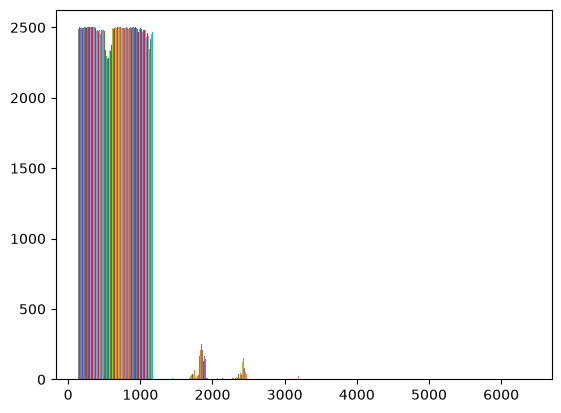

In [107]:
plt.hist(raw_arr[:, :, 0], bins=5)
plt.show()

In [15]:
red = raw_arr[:,:,0]

In [27]:
red_neg = red[red<0]

In [31]:
print(red_neg)

[-23 -17 -14 ... -16 -91  -8]


In [29]:
for i, b in enumerate(Bands):
    out_path = OUTPUT_DIR / f"{b}_{year}_Q{quarter}.tif"
    save_geotiff(raw_arr[:, : , i], bbox, out_path)

  → Saved: _output/B04_2020_Q1.tif  (2500×2500 px, 11.1 MB)
  → Saved: _output/B08_2020_Q1.tif  (2500×2500 px, 12.5 MB)
  → Saved: _output/observations_2020_Q1.tif  (2500×2500 px, 1.1 MB)
  → Saved: _output/dataMask_2020_Q1.tif  (2500×2500 px, 0.1 MB)
